In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# LOAD DATA
# ============================================================

In [3]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

In [4]:
df = pd.read_csv(url)

In [5]:
df.shape

(7043, 21)

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# ============================================================
# EDA
# ============================================================

In [8]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
print("\n ---- Null Values ----")
df.isnull().sum()


 ---- Null Values ----


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].unique())

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
Churn ['No' 'Yes']


In [11]:
print("\n ---- Target Distribution ---- ")
df["Churn"].value_counts()


 ---- Target Distribution ---- 


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("\n Total Charges null after conversion:", df["TotalCharges"].isnull().sum() )


 Total Charges null after conversion: 11


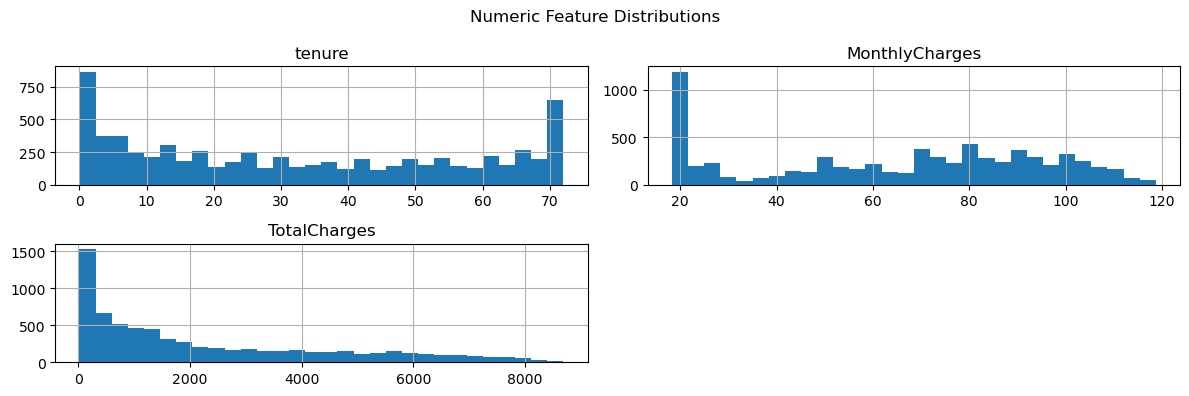

In [13]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[num_cols].hist(bins=30, figsize=(12,4)) 
plt.suptitle("Numeric Feature Distributions")
plt.tight_layout()
plt.show()

In [14]:
df[num_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


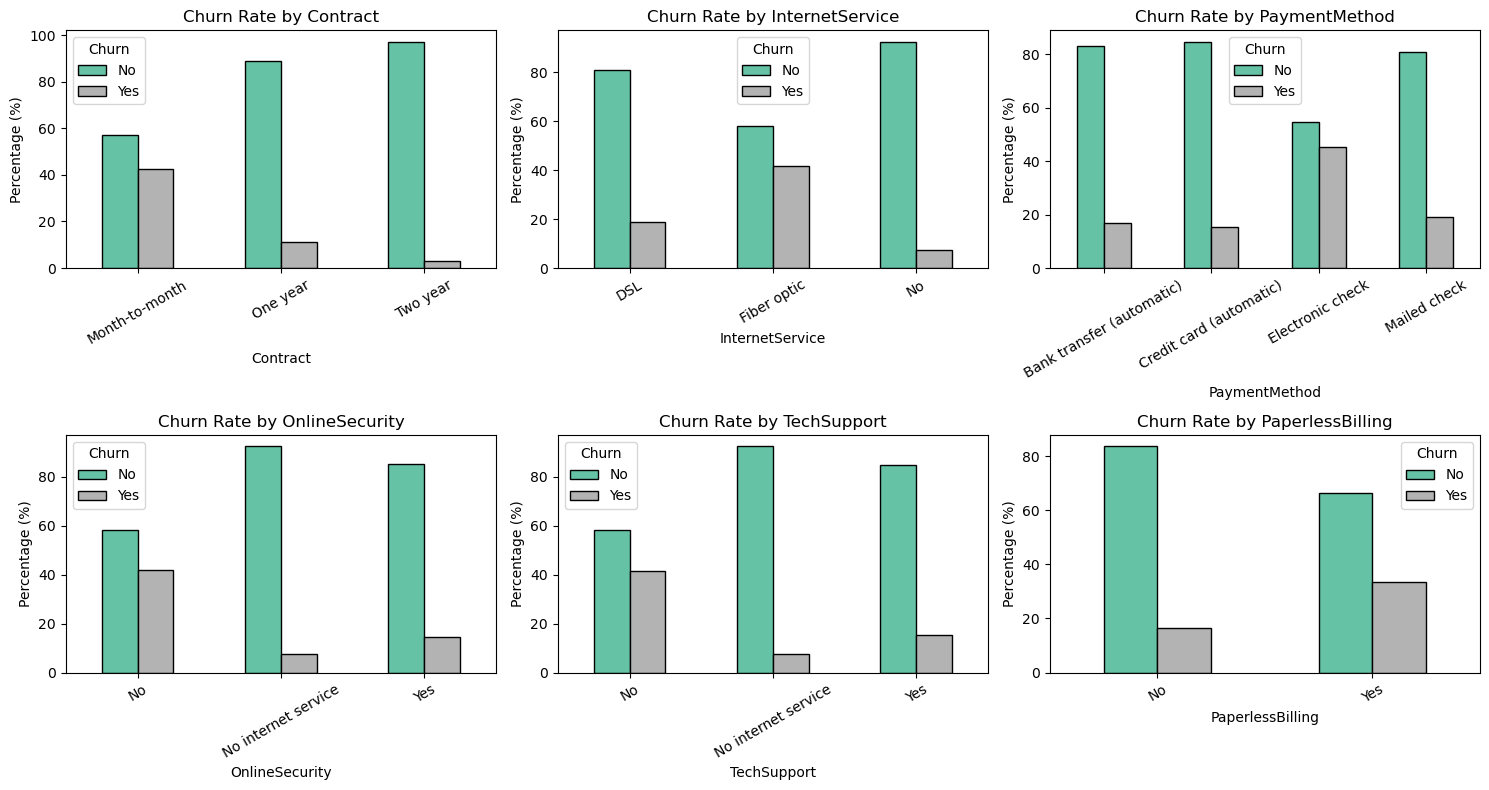

In [15]:
cat_cols = ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport", "PaperlessBilling"]
fig, axes =  plt.subplots(2,3, figsize= (15,8))
for ax, col in zip(axes.flatten(), cat_cols):
    ct = pd.crosstab(df[col], df["Churn"], normalize="index") * 100 
    ct.plot(kind="bar", ax=ax, colormap = "Set2", edgecolor="black")
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Percentage (%)")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# CATEGORICAL COLUMNS — UNIQUE VALUE CHECK
# ============================================================

In [17]:
print("=== Categorical Column Value Counts ===\n")
for col in df.select_dtypes(include='object').columns:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}\n")

=== Categorical Column Value Counts ===

--- customerID ---
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64
Unique values: 7043

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64
Unique values: 2

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Unique values: 2

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
Unique values: 2

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
Unique values: 2

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
Unique values: 3

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
Unique values: 3

--- O

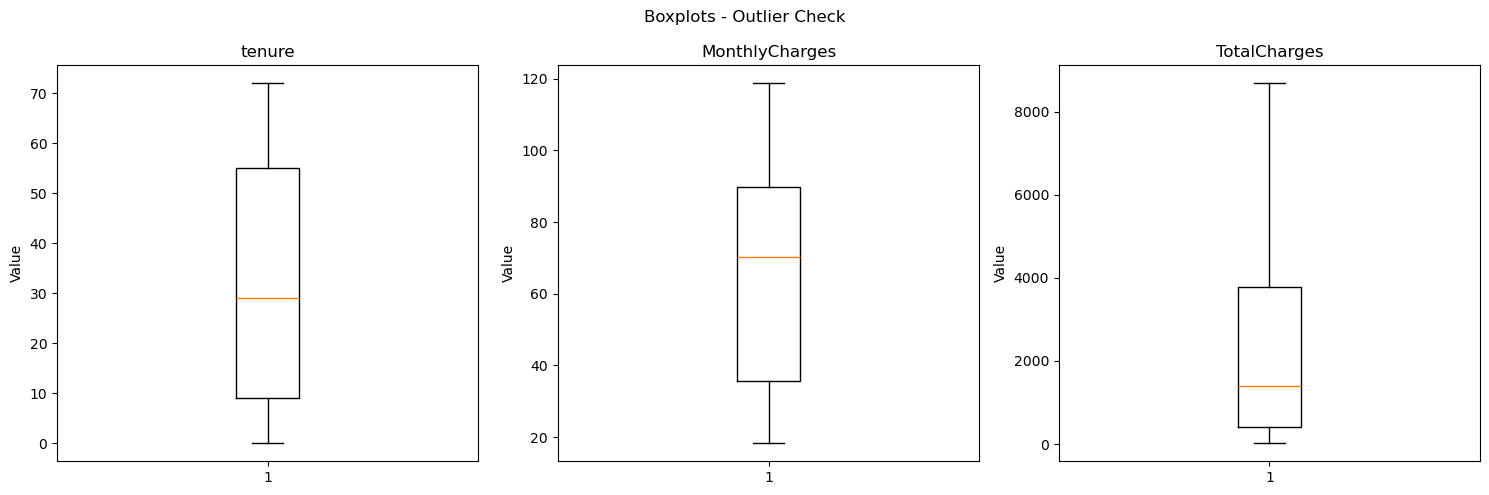

In [30]:
fig, axes = plt.subplots(1,3, figsize=(15,5))
for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
    ax.set_ylabel("Value")
plt.suptitle("Boxplots - Outlier Check")
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# PREPROCESSING
# ============================================================

In [20]:
# Drop customerID (identifier, no predictive value)
df.drop(columns=["customerID"], inplace=True)

In [21]:
# TotalCharges: impute missing with median (11 rows)
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

In [22]:
# Target encode: Churn -> 0/1
df["Churn"] = df["Churn"].map({"No":0, "Yes":1})

In [23]:
# Binary columns: Yes/No -> 1/0
binary_cols = ["Partner","Dependents", "PhoneService", "PaperlessBilling", "MultipleLines", "OnlineSecurity", "OnlineBackup", 
              "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

In [24]:
# These have 'No phone service' / 'No internet service' → treat as 'No'
for col in binary_cols:
    df[col] = df[col].replace({"No phone service": "No", "No internet service": "No"})
    df[col] = df[col].map({"No": 0, "Yes": 1})

In [25]:
# gender: Male/Female → 1/0
df["gender"] = df["gender"].map({"Male": 1, "Female":0})

In [26]:
# One-hot encode remaining nominal categoricals
nominal_cols = ["InternetService", "Contract", "PaymentMethod"]
df = pd.get_dummies(df, columns= nominal_cols, drop_first = True)

print("Shape after encoding:", df.shape)
print(df.dtypes)

Shape after encoding: (7043, 24)
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
InternetService_Fiber optic                 bool
InternetService_No                          bool
Contract_One year                   

In [35]:
# ============================================================
# OUTLIER CHECK — IQR SUMMARY
# ============================================================

In [36]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower) | (df[col] > upper )).sum()
    print(f"{col}: lower= {lower:.2f}, upper={upper:.2f}, outlier_count = {outlier_count}")
    

tenure: lower= -60.00, upper=124.00, outlier_count = 0
MonthlyCharges: lower= -46.02, upper=171.38, outlier_count = 0
TotalCharges: lower= -4674.34, upper=8863.16, outlier_count = 0


In [37]:
# No significant outliers detected via IQR method.
# Skipping IQR capping as no capping is needed for this dataset.

In [38]:
# ============================================================
# MULTICOLLINEARITY — VIF
# ============================================================

In [40]:
# Random Forest is tree-based → not affected by multicollinearity
# Compute VIF for completeness and documentation

In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

feature_cols = [c for c in  df.columns if c!= "Churn"]
X_vif = df[feature_cols].astype(float)

vif_data = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

print(vif_data)

                                  Feature         VIF
14                         MonthlyCharges  211.337442
5                            PhoneService   47.023597
15                           TotalCharges   21.107439
4                                  tenure   19.951591
16            InternetService_Fiber optic   17.608109
17                     InternetService_No    8.207544
12                        StreamingMovies    5.062062
11                            StreamingTV    4.923995
19                      Contract_Two year    3.461217
9                        DeviceProtection    2.993056
13                       PaperlessBilling    2.954543
21         PaymentMethod_Electronic check    2.953982
8                            OnlineBackup    2.907704
6                           MultipleLines    2.859378
2                                 Partner    2.827264
10                            TechSupport    2.757361
7                          OnlineSecurity    2.683745
22             PaymentMethod

In [50]:
# High VIF detected for MonthlyCharges, TotalCharges, tenure.
# This is expected: TotalCharges = tenure x MonthlyCharges (mathematical dependency).
# Random Forest is tree-based and does not assume feature independence,
# so multicollinearity does not affect model performance.
# No features dropped.

In [51]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

In [53]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn"])
y= df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42, stratify=y)

print("Train class dist:\n", y_train.value_counts)
print("Test clas dist:\n", y_test.value_counts())

Train class dist:
 <bound method IndexOpsMixin.value_counts of 3738    0
3151    0
4860    0
3867    0
3810    0
       ..
6303    0
6227    1
4673    1
2710    0
5639    0
Name: Churn, Length: 5634, dtype: int64>
Test clas dist:
 Churn
0    1035
1     374
Name: count, dtype: int64


In [54]:
# ============================================================
# SMOTE — applied only on training set
# ============================================================

In [55]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train,y_train)
print("\n After SMOTE:", pd.Series(y_train_sm).value_counts())


 After SMOTE: Churn
0    4139
1    4139
Name: count, dtype: int64


In [56]:
# ============================================================
# BASELINE RANDOM FOREST
# ============================================================

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

rf_base =RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train_sm, y_train_sm)

y_pred_base = rf_base.predict(X_test)
y_prob_base = rf_base.predict_proba(X_test)[:,1]

print("Baseline ROC-AUC:", roc_auc_score(y_test, y_prob_base).round(4))
print(classification_report(y_test, y_pred_base))

Baseline ROC-AUC: 0.8183
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1035
           1       0.57      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [61]:
# ============================================================
# HYPERPARAMETER TUNING — GridSearchCV
# ============================================================

In [62]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

param_grid = {
    "n_estimators": [100,200],
    "max_depth": [None, 10,20],
    "min_samples_leaf": [1,2,4],
    "max_features": ["sqrt","log"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sm,y_train_sm)

print("Best Params:", grid_search.best_params_)
print("Best CV AUC:", round(grid_search.best_score_, 4))
rf_best = grid_search.best_estimator_    


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV AUC: 0.9239


In [63]:
# ============================================================
# THRESHOLD TUNING
# ============================================================

In [65]:
from sklearn.metrics import f1_score

y_prob = rf_best.predict_proba(X_test)[:,1]

thresholds = np.arange(0.30,0.65,0.01)
f1_scores = [f1_score(y_test, (y_prob >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Best Threshold: {best_thresh:.2f}, F1: {max(f1_scores):.4f}")

y_pred_tuned = (y_prob >= best_thresh).astype(int)

Best Threshold: 0.34, F1: 0.6141


In [66]:
# ============================================================
# FINAL METRICS
# ============================================================


 ---- Classification Report ----
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC:   0.8249
Log Loss:  0.4605
Cohen Kappa:  0.4307


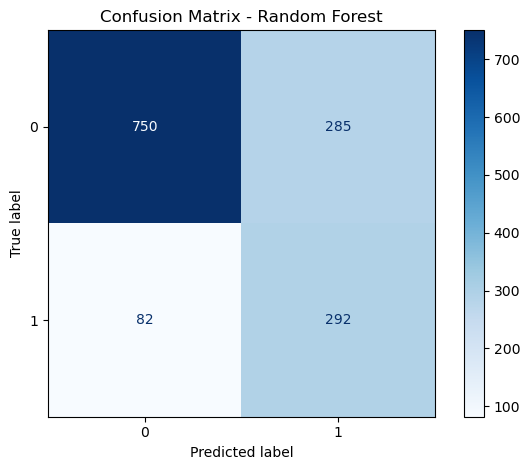

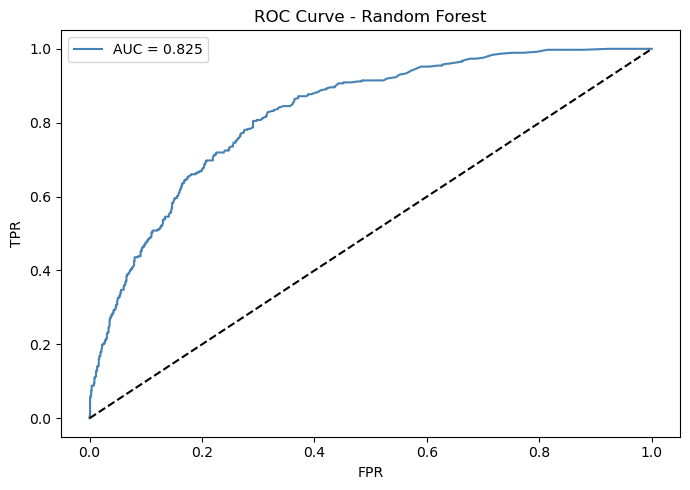

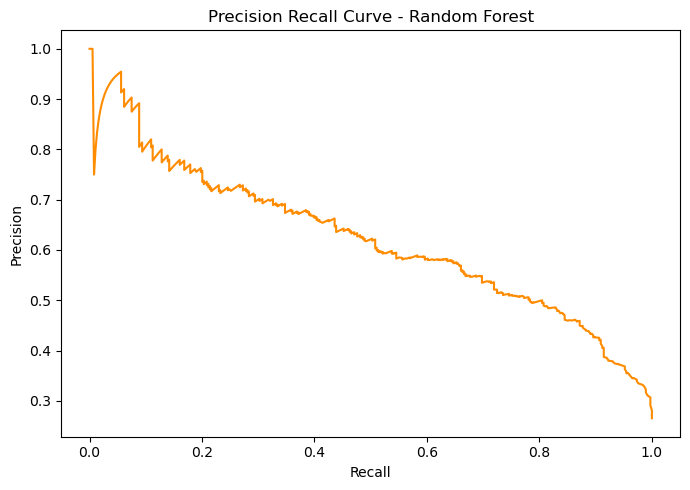

In [73]:
from sklearn.metrics import classification_report, log_loss, cohen_kappa_score, precision_recall_curve, ConfusionMatrixDisplay, roc_curve

print("\n ---- Classification Report ----")
print(classification_report(y_test,y_pred_tuned))
print("ROC-AUC:  ",  round(roc_auc_score(y_test,y_prob), 4))
print("Log Loss: ",  round(log_loss(y_test,y_prob), 4))
print("Cohen Kappa: ", round(cohen_kappa_score(y_test,y_pred_tuned), 4))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_tuned, cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test,y_prob):.3f}", color="steelblue")
plt.plot([0,1],[0,1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

# Precision Recall Curve
prec, rec, _ = precision_recall_curve(y_test,y_prob)
plt.figure(figsize=(7,5))
plt.plot(rec,prec, color = "darkorange")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve - Random Forest")
plt.tight_layout()
plt.show()


In [75]:
# ============================================================
# FEATURE IMPORTANCE (MDI — Mean Decrease Impurity)
# ============================================================

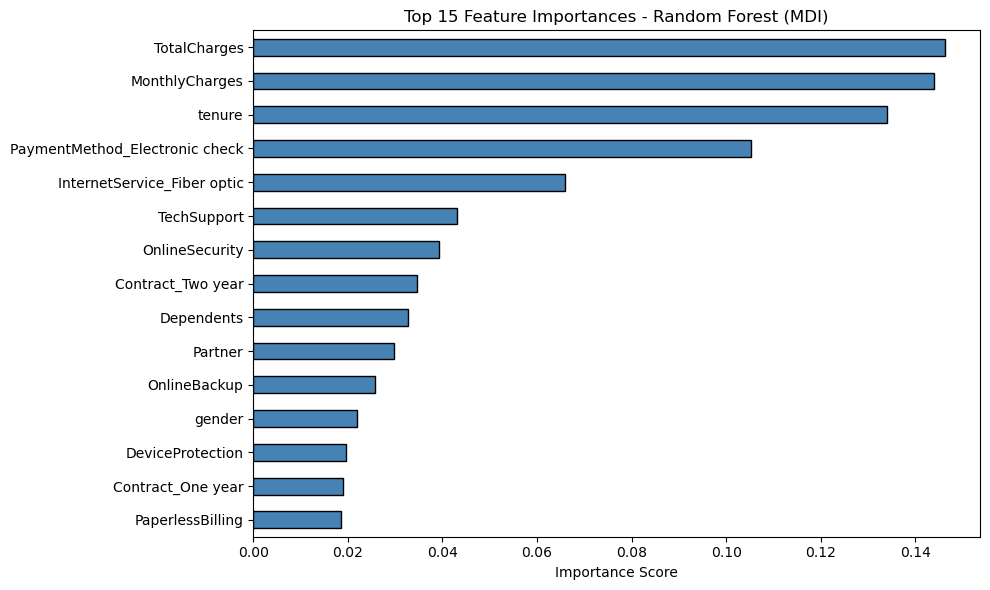

In [76]:
importances = pd.Series(rf_best.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
importances.plot(kind="barh", color="steelblue", edgecolor="black")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Random Forest (MDI)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [77]:
# ============================================================
# PERMUTATION IMPORTANCE (more reliable than MDI)
# ============================================================

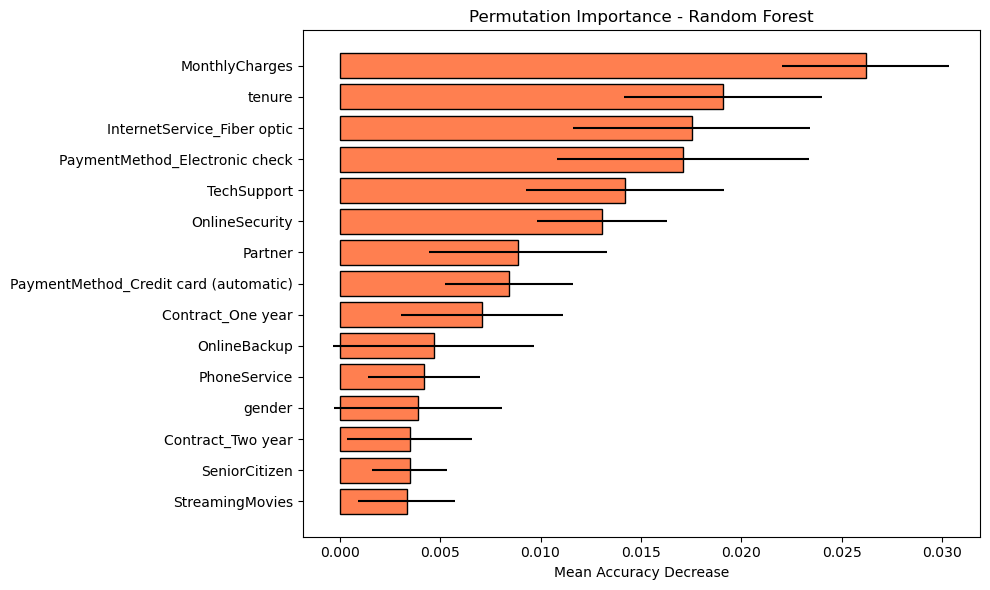

In [78]:
from sklearn.inspection import permutation_importance
perm_imp = permutation_importance(rf_best,X_test,y_test, n_repeats=10, random_state=42, n_jobs=-1)

perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_imp.importances_mean,
    "Std": perm_imp.importances_std
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(perm_df["Feature"], perm_df["Importance"],
        xerr= perm_df["Std"], color="coral", edgecolor="black")
plt.gca().invert_yaxis()
plt.title("Permutation Importance - Random Forest")
plt.xlabel("Mean Accuracy Decrease")
plt.tight_layout()
plt.show()


In [80]:
# ============================================================
# CROSS-VALIDATION
# ============================================================

In [81]:
from sklearn.model_selection import cross_validate
cv_results = cross_validate(
    rf_best, X_train_sm, y_train_sm,
    cv= cv,
    scoring= ["roc_auc", "f1"],
    return_train_score = True
)

print(f"CV ROC-AUC : {cv_results["test_roc_auc"].mean():.3f} ± {cv_results["test_roc_auc"].std():.3f}")
print(f"CV F1      : {cv_results["test_f1"].mean():.3f} ± {cv_results["test_f1"].std():.3f} ")
print("\n Overfit Check:")
print(f"Train AUC  : {cv_results["train_roc_auc"].mean():.3f}")
print(f"Test AUC   : {cv_results["test_roc_auc"].mean():.3f}")
print(f"AUC Gap    : {(cv_results["train_roc_auc"].mean() - cv_results["test_roc_auc"].mean()):.3f}")


CV ROC-AUC : 0.924 ± 0.005
CV F1      : 0.847 ± 0.007 

 Overfit Check:
Train AUC  : 1.000
Test AUC   : 0.924
AUC Gap    : 0.076


In [82]:
# Train AUC = 1.0 indicates the model memorizes training data.
# However, Test AUC = 0.924 and low CV std (0.005) suggest
# the model still generalizes well.
# Mild overfitting controlled by ensemble averaging across 200 trees.
# Can be reduced by increasing min_samples_leaf or reducing max_depth.